# Notebook 1 — Génération du dataset SIBTEL réaliste

**Objectif** : Créer 10 000 transactions de télécompensation conformes à la norme SIBTEL tunisienne.

**Caractéristiques** :
- RIBs tunisiens avec clé modulo 97 mathématiquement valide
- Codes banques officiels BCT (BNA, BIAT, STB, BTL, etc.)
- Codes rejet conformes à la norme SIBTEL
- 10 features 100% calculables depuis un vrai fichier ENV/PAK
- Taux de rejet réaliste : ~5% (cohérent avec les statistiques BCT)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta

np.random.seed(42)
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (12, 5)

print('Imports OK')

Imports OK


In [2]:
# Banques tunisiennes (codes officiels BCT)
BANQUES = {
    '01': 'BNA',     '02': 'BIAT',    '03': 'STB',
    '04': 'BH',      '05': 'ATB',     '07': 'UBCI',
    '08': 'UIB',     '10': 'AMEN',    '11': 'ATTIJARI',
    '12': 'BTK',     '14': 'BFT',     '17': 'ZITOUNA',
    '20': 'QNB',     '25': 'WIFAK',   '26': 'BTL',
}

# Types de valeur SIBTEL
TYPES_VALEUR = {
    '10': 'Virement',
    '20': 'Prelevement',
    '30': 'Cheque',
    '31': 'CNP Partiel',
    '32': 'ARP',
    '40': 'Lettre de change',
    '84': 'Papillon',
}

# Codes de rejet SIBTEL
CODES_REJET = {
    '01': 'Provision insuffisante',
    '02': 'Compte cloture',
    '03': 'Opposition sur cheque',
    '04': 'Compte bloque',
    '07': 'RIB inexistant ou invalide',
    '08': 'Compte interdit (FIPI/FCC)',
    '09': 'Echeance depassee',
    '10': 'Code banque destinataire invalide',
    '15': 'Montant incoherent',
}

# Situations donneur (norme SIBTEL)
SITUATIONS_DONNEUR = {
    '0': 'Normal',
    '1': 'Interdit de chequier',
    '2': 'Compte cloture',
    '3': 'Compte bloque',
}

# Types de compte
TYPES_COMPTE = {
    '1': 'Courant',
    '2': 'Epargne',
    '3': 'Devise',
}

print(f'{len(BANQUES)} banques tunisiennes')
print(f'{len(TYPES_VALEUR)} types de valeur SIBTEL')
print(f'{len(CODES_REJET)} codes de rejet')

15 banques tunisiennes
7 types de valeur SIBTEL
9 codes de rejet


In [3]:
def calculer_cle_rib(banque, agence, compte):
    """
    Calcule la cle RIB tunisien (2 chiffres, modulo 97).
    Format RIB : banque(2) + agence(3) + compte(13) + cle(2) = 20 chiffres
    """
    rib_partiel = banque + agence + compte
    cle = 97 - (int(rib_partiel + '00') % 97)
    return str(cle).zfill(2)

def generer_rib(banque=None, valide=True):
    """Genere un RIB tunisien (20 chiffres) avec ou sans cle valide."""
    if banque is None:
        banque = np.random.choice(list(BANQUES.keys()))
    agence = str(np.random.randint(1, 999)).zfill(3)
    # Generer un numero de compte de 13 chiffres (concatenation pour eviter int32)
    compte = ''.join([str(np.random.randint(0, 10)) for _ in range(13)])
    
    if valide:
        cle = calculer_cle_rib(banque, agence, compte)
    else:
        # Cle volontairement fausse
        cle_correcte = calculer_cle_rib(banque, agence, compte)
        cle = str((int(cle_correcte) + np.random.randint(1, 90)) % 100).zfill(2)
    
    return banque + agence + compte + cle

def verifier_rib(rib):
    """Verifie si la cle d'un RIB est correcte (modulo 97)."""
    if len(rib) != 20 or not rib.isdigit():
        return False
    banque, agence, compte, cle = rib[:2], rib[2:5], rib[5:18], rib[18:]
    return calculer_cle_rib(banque, agence, compte) == cle

# Test : generer un RIB valide et un invalide
rib_ok = generer_rib('26', valide=True)
rib_ko = generer_rib('26', valide=False)

print(f'RIB BTL valide   : {rib_ok}  -> verif modulo 97: {verifier_rib(rib_ok)}')
print(f'RIB BTL invalide : {rib_ko}  -> verif modulo 97: {verifier_rib(rib_ko)}')

RIB BTL valide   : 26103374692674377273  -> verif modulo 97: True
RIB BTL invalide : 26662417514095809275  -> verif modulo 97: False


In [4]:
def generer_transaction(idx):
    """Genere une transaction SIBTEL realiste."""
    
    # Type de valeur (poids realistes : virements > cheques > autres)
    type_valeur = np.random.choice(
        list(TYPES_VALEUR.keys()),
        p=[0.55, 0.15, 0.18, 0.04, 0.03, 0.04, 0.01]
    )
    
    # Banques (BTL = code 26, sur-representee car c'est notre banque)
    poids_banques = [0.06, 0.08, 0.06, 0.05, 0.04, 0.03, 0.04,
                     0.05, 0.04, 0.03, 0.03, 0.02, 0.02, 0.02, 0.43]
    banque_don  = np.random.choice(list(BANQUES.keys()), p=poids_banques)
    banque_dest = np.random.choice(list(BANQUES.keys()))
    # 70% des transactions sont inter-banques
    while banque_dest == banque_don and np.random.random() > 0.3:
        banque_dest = np.random.choice(list(BANQUES.keys()))
    
    # Montant (distribution log-normale realiste)
    montant = round(np.random.lognormal(mean=7.5, sigma=1.2), 3)
    montant = min(montant, 500000)
    
    # RIBs (95% valides au depart)
    rib_don_valide  = np.random.random() > 0.05
    rib_dest_valide = np.random.random() > 0.05
    
    # Date operation (90 derniers jours, jours ouvrables)
    date_op = datetime.now() - timedelta(days=int(np.random.randint(0, 90)))
    while date_op.weekday() >= 5:
        date_op -= timedelta(days=1)
    
    # Echeance (LDC + prelevements peuvent etre depassees)
    echeance_depassee = 0
    if type_valeur in ['20', '40']:
        if np.random.random() < 0.05:
            echeance_depassee = 1
    
    # Situation donneur (95% normaux)
    situation_donneur = np.random.choice(
        list(SITUATIONS_DONNEUR.keys()),
        p=[0.95, 0.02, 0.02, 0.01]
    )
    
    # Type compte
    type_compte = np.random.choice(['1', '2', '3'], p=[0.85, 0.12, 0.03])
    
    # Feature derivee : meme banque (transferts intra-bancaires)
    meme_banque = int(banque_don == banque_dest)
    
    return {
        'id':                      idx,
        'type_valeur':             type_valeur,
        'montant':                 montant,
        'code_banque_don':         banque_don,
        'code_banque_dest':        banque_dest,
        'rib_donneur':             generer_rib(banque_don,  valide=rib_don_valide),
        'rib_beneficiaire':        generer_rib(banque_dest, valide=rib_dest_valide),
        'rib_donneur_valide':      int(rib_don_valide),
        'rib_beneficiaire_valide': int(rib_dest_valide),
        'date_operation':          date_op.strftime('%Y%m%d'),
        'echeance_depassee':       echeance_depassee,
        'meme_banque':             meme_banque,
        'situation_donneur':       situation_donneur,
        'type_compte':             type_compte,
    }

print('Generation de 10 000 transactions en cours...')
transactions = [generer_transaction(i+1) for i in range(10000)]
df = pd.DataFrame(transactions)
print(f'{len(df)} transactions generees')
df.head(3)

Generation de 10 000 transactions en cours...
10000 transactions generees


,id,type_valeur,montant,code_banque_don,code_banque_dest,rib_donneur,rib_beneficiaire,rib_donneur_valide,rib_beneficiaire_valide,date_operation,echeance_depassee,meme_banque,situation_donneur,type_compte
0,1,40,454.323,12,05,12898367203173155967,05772519193768741402,1,1,20260312,0,0,0,1
1,2,20,2837.951,26,17,26129772072204969839,17028687106674275240,1,1,20260424,0,0,0,1
2,3,10,3169.578,02,25,02554260334663625118,25682845396860088359,1,1,20260414,0,0,0,1


In [6]:
def appliquer_regles_rejet(row):
    """
    Applique les regles SIBTEL pour determiner si une transaction est rejetee.
    Retourne (a_ete_rejete, code_rejet).
    """
    
    # Regle 1 : RIB invalide -> code 07
    if row['rib_donneur_valide'] == 0 or row['rib_beneficiaire_valide'] == 0:
        if np.random.random() < 0.85:
            return (1, '07')
    
    # Regle 2 : Compte cloture -> code 02
    if row['situation_donneur'] == '2':
        return (1, '02')
    
    # Regle 3 : Compte bloque -> code 04
    if row['situation_donneur'] == '3':
        return (1, '04')
    
    # Regle 4 : Compte interdit + cheque -> code 08
    if row['situation_donneur'] == '1' and row['type_valeur'] in ['30', '31', '32']:
        return (1, '08')
    
    # Regle 5 : Echeance depassee -> code 09
    if row['echeance_depassee'] == 1:
        if np.random.random() < 0.80:
            return (1, '09')
    
    # Regle 6 : Montant aberrant -> code 15
    if row['montant'] > 250000 and np.random.random() < 0.15:
        return (1, '15')
    
    # Regle 7 : Cheque inter-banque + gros montant
    if (row['type_valeur'] in ['30', '31', '32'] and 
        row['meme_banque'] == 0 and 
        row['montant'] > 50000 and 
        np.random.random() < 0.08):
        return (1, '01')
    
    # Regle 8 : Bruit aleatoire
    if np.random.random() < 0.005:
        return (1, np.random.choice(['03', '10']))
    
    return (0, '00')

# Appliquer les regles a toutes les transactions
df[['a_ete_rejete', 'code_rejet']] = df.apply(
    appliquer_regles_rejet, axis=1, result_type='expand'
)

taux = df['a_ete_rejete'].mean() * 100
print(f'Taux de rejet : {taux:.2f}% ({df["a_ete_rejete"].sum()} transactions sur {len(df)})')
print()
print('Repartition par code de rejet :')
rejets = df[df['a_ete_rejete']==1]['code_rejet'].value_counts()
for code, n in rejets.items():
    motif = CODES_REJET.get(code, '?')
    print(f'  {code} - {motif:40s} : {n:4d} cas')

Taux de rejet : 12.80% (1280 transactions sur 10000)

Repartition par code de rejet :
  07 - RIB inexistant ou invalide               :  847 cas
  02 - Compte cloture                           :  184 cas
  04 - Compte bloque                            :   95 cas
  09 - Echeance depassee                        :   66 cas
  08 - Compte interdit (FIPI/FCC)               :   43 cas
  03 - Opposition sur cheque                    :   23 cas
  10 - Code banque destinataire invalide        :   22 cas


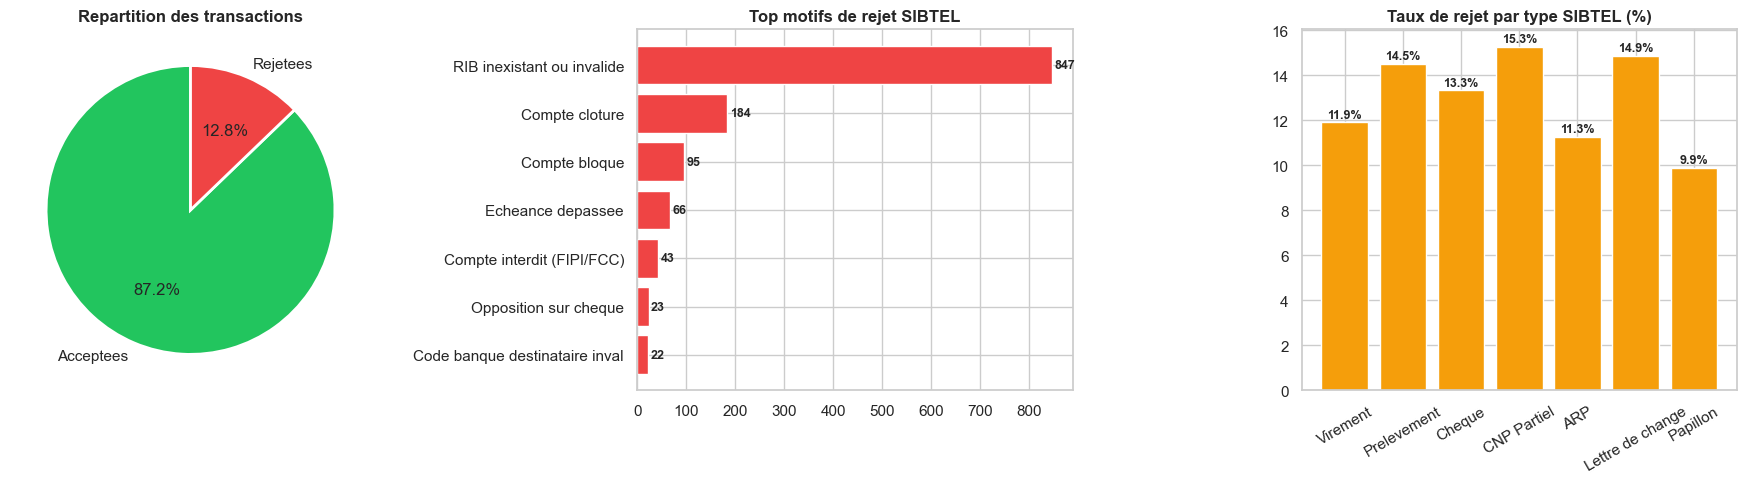


dataset.csv sauvegarde : 10000 lignes x 16 colonnes
exploration_dataset.png sauvegarde

  NOTEBOOK 1 TERMINE
Pret pour le Notebook 2 (entrainement du modele)


In [7]:
# Graphiques pour la soutenance
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Camembert acceptees vs rejetees
counts = df['a_ete_rejete'].value_counts()
axes[0].pie(counts, labels=['Acceptees', 'Rejetees'],
            colors=['#22c55e', '#ef4444'], autopct='%1.1f%%',
            startangle=90, wedgeprops={'edgecolor':'white','linewidth':2})
axes[0].set_title('Repartition des transactions', fontweight='bold')

# 2. Top motifs de rejet
rejets_top = df[df['a_ete_rejete']==1]['code_rejet'].value_counts().head(8)
labels = [CODES_REJET.get(c, c)[:30] for c in rejets_top.index]
axes[1].barh(labels, rejets_top.values, color='#ef4444', edgecolor='white')
axes[1].set_title('Top motifs de rejet SIBTEL', fontweight='bold')
axes[1].invert_yaxis()
for i, v in enumerate(rejets_top.values):
    axes[1].text(v + 5, i, str(v), va='center', fontweight='bold', fontsize=9)

# 3. Taux de rejet par type SIBTEL
pivot = df.groupby('type_valeur')['a_ete_rejete'].mean() * 100
labels_t = [TYPES_VALEUR[t] for t in pivot.index]
axes[2].bar(labels_t, pivot.values, color='#f59e0b', edgecolor='white')
axes[2].set_title('Taux de rejet par type SIBTEL (%)', fontweight='bold')
axes[2].tick_params(axis='x', rotation=30)
for i, v in enumerate(pivot.values):
    axes[2].text(i, v + 0.2, f'{v:.1f}%', ha='center', fontweight='bold', fontsize=9)

plt.tight_layout()
plt.savefig('exploration_dataset.png', dpi=120, bbox_inches='tight')
plt.show()

# Export du dataset
df.to_csv('dataset.csv', index=False)
print(f'\ndataset.csv sauvegarde : {df.shape[0]} lignes x {df.shape[1]} colonnes')
print(f'exploration_dataset.png sauvegarde')
print()
print('=' * 55)
print('  NOTEBOOK 1 TERMINE')
print('=' * 55)
print('Pret pour le Notebook 2 (entrainement du modele)')